# A character-level autoregressive model

This project builds the smallest useful language model: given one character, estimate the probability of the next character. The model does not know words, grammar, or meaning. It only learns which characters tend to follow which other characters in a small text corpus.

That simplicity is useful. The entire model is a table of conditional probabilities, so we can inspect the data, the learned distribution, the validation score, and the generated text without hiding any step inside a large framework.

## Project question

For a character sequence `c₁, c₂, …, cₙ`, a bigram language model estimates

```text
P(cₜ₊₁ | cₜ)
```

The model then generates text one character at a time. After observing the current character, it samples the next character from that row of the probability table and repeats. This is autoregressive generation: every new character becomes the context for the next prediction.

## Corpus choice and data limit

The corpus is `stas/gutenberg-100` on Hugging Face. Its dataset card describes a small public-domain Project Gutenberg collection intended for quick experiments. We stream the dataset and keep only two books: *Frankenstein* and *The Time Machine*. The notebook therefore never trains on more than those two book texts, even though the hosted dataset contains more records.

The two books are useful for this first model because they provide ordinary English characters, punctuation, paragraph breaks, and dialogue. The goal is not to produce a strong literary model. The goal is to make the conditional-probability mechanism measurable and inspectable.

In [1]:
from ast import literal_eval
import re

from datasets import load_dataset

DATASET_NAME = "stas/gutenberg-100"
BOOK_TITLES = {
    "Frankenstein; Or, The Modern Prometheus",
    "The Time Machine",
}


def decode_dataset_text(value):
    """Return the dataset's text field as a normal Python string."""
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="replace")
    if isinstance(value, str) and value.startswith("b'"):
        return literal_eval(value).decode("utf-8", errors="replace")
    return str(value)


records = load_dataset(DATASET_NAME, split="train")
books = {}

for record in records:
    title = record["title"].strip("'\"")
    if title in BOOK_TITLES:
        books[title] = decode_dataset_text(record["text"])
    if len(books) == len(BOOK_TITLES):
        break

missing_titles = BOOK_TITLES - books.keys()
if missing_titles:
    raise RuntimeError(f"Missing requested books: {sorted(missing_titles)}")

for title in sorted(books):
    print(f"{title}: {len(books[title]):,} characters")

Frankenstein; Or, The Modern Prometheus: 465,722 characters
The Time Machine: 202,497 characters


The first inspection is deliberately simple. Before cleaning anything, check whether the selected records contain Gutenberg headers, unusual byte markers, or characters that would make the alphabet unnecessarily large.

In [2]:
for title in sorted(books):
    text = books[title]
    print(f"\n{title}")
    print("sample:", repr(text[:160]))
    print("unique characters:", len(set(text)))


Frankenstein; Or, The Modern Prometheus
sample: '\ufeffThe Project Gutenberg eBook of Frankenstein; Or, The Modern Prometheus\r\n    \r\nThis ebook is for the use of anyone anywhere in the United States and\r\nmost other'
unique characters: 98

The Time Machine
sample: '\ufeffThe Project Gutenberg eBook of The Time Machine\r\n    \r\nThis ebook is for the use of anyone anywhere in the United States and\r\nmost other parts of the world at '
unique characters: 94


## Clean the text without erasing its structure

The model should learn ordinary prose rather than the metadata surrounding an ebook. We remove the Gutenberg header and footer when the standard markers are present, normalize line endings, and keep spaces, punctuation, and paragraph breaks. Those characters are part of the distribution we want the model to learn.

In [3]:
def remove_gutenberg_wrapper(text):
    """Remove the standard Project Gutenberg header and footer when present."""
    start_marker = "*** START OF"
    end_marker = "*** END OF"
    start = text.find(start_marker)
    end = text.find(end_marker)
    if start >= 0 and end > start:
        text = text[text.find("\n", start) + 1 : end]
    return text


def clean_book(text):
    """Normalize formatting while preserving prose, punctuation, and paragraphs."""
    text = remove_gutenberg_wrapper(text)
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = text.replace("\ufeff", "")
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


clean_books = {title: clean_book(text) for title, text in books.items()}
corpus = "\n\n".join(clean_books[title] for title in sorted(clean_books))

print("books used:", len(clean_books))
print("corpus characters:", f"{len(corpus):,}")
print("alphabet size:", len(set(corpus)))
print("clean sample:", repr(corpus[:240]))

books used: 2
corpus characters: 617,756
alphabet size: 93
clean sample: 'Produced by Greg Weeks, Mary Meehan and the Online\nDistributed Proofreading Team at http://www.pgdp.net\n\n                             FRANKENSTEIN:\n\n                                  OR,\n\n                         THE MODERN PROMETHEUS.\n\n   '


## Build a character vocabulary

Every character receives an integer ID. The mapping is the complete interface between text and the model: `encode` turns characters into integers, and `decode` turns sampled integers back into text. A character-level model does not need a word tokenizer, vocabulary file, or unknown-token rule because every character observed in the corpus is represented directly.

In [4]:
import torch

characters = sorted(set(corpus))
character_to_id = {character: index for index, character in enumerate(characters)}
id_to_character = {index: character for character, index in character_to_id.items()}


def encode(text):
    return torch.tensor([character_to_id[character] for character in text], dtype=torch.long)


def decode(ids):
    return ''.join(id_to_character[int(index)] for index in ids)


encoded_corpus = encode(corpus)
print('vocabulary size:', len(characters))
print('round-trip works:', decode(encoded_corpus[:80]) == corpus[:80])

vocabulary size: 93
round-trip works: True


## Make a leakage-resistant train/validation split

A language model predicts the next character from the previous one. We split each book in order, using the first 90 percent for training and the final 10 percent for validation. The validation characters are later in each book, so the model is not evaluated on randomly interleaved neighbors from the same passage.

In [5]:
train_parts = []
validation_parts = []

for title, text in clean_books.items():
    split_index = int(0.9 * len(text))
    train_parts.append(encode(text[:split_index]))
    validation_parts.append(encode(text[split_index:]))

train_ids = torch.cat(train_parts)
validation_ids = torch.cat(validation_parts)

print('training characters:', f'{len(train_ids):,}')
print('validation characters:', f'{len(validation_ids):,}')

training characters: 555,977
validation characters: 61,777


## Start with a unigram baseline

Before conditioning on the previous character, estimate one probability for each character:

```text
P(c)
```

This baseline knows which characters are common, but it cannot tell that `q` is usually followed by `u`, or that a newline often follows a period. Its validation loss gives us a reference point for the conditional model.

In [6]:
def negative_log_likelihood(probabilities, ids):
    """Average negative log probability assigned to a sequence of IDs."""
    return float(-probabilities[ids].clamp_min(1e-12).log().mean())


alphabet_size = len(characters)
unigram_counts = torch.bincount(train_ids, minlength=alphabet_size).double()
unigram_probabilities = unigram_counts / unigram_counts.sum()
unigram_loss = negative_log_likelihood(unigram_probabilities, validation_ids)
unigram_perplexity = torch.exp(torch.tensor(unigram_loss))

print(f"unigram validation NLL: {unigram_loss:.3f}")
print(f"unigram validation perplexity: {unigram_perplexity.item():.2f}")

unigram validation NLL: 3.072
unigram validation perplexity: 21.60


## Estimate the conditional probability table

For the bigram model, count transitions rather than characters. Row `i`, column `j` records how often character `j` appeared immediately after character `i` in the training text. Normalizing each row gives an estimate of `P(next=j | current=i)`.

Some transitions will never appear in the finite corpus. Additive smoothing gives every transition a small nonzero probability, which keeps the model well-defined when it encounters a rare character during validation or generation.

In [7]:
def count_transitions(current_ids, next_ids, vocabulary_size):
    """Count every observed (current character, next character) pair."""
    counts = torch.zeros((vocabulary_size, vocabulary_size), dtype=torch.float64)
    counts.index_put_(
        (current_ids, next_ids),
        torch.ones_like(current_ids, dtype=torch.float64),
        accumulate=True,
    )
    return counts


train_current = train_ids[:-1]
train_next = train_ids[1:]
transition_counts = count_transitions(train_current, train_next, alphabet_size)

smoothing = 0.5
smoothed_counts = transition_counts + smoothing
transition_probabilities = smoothed_counts / smoothed_counts.sum(dim=1, keepdim=True)

validation_probabilities = transition_probabilities[validation_ids[:-1], validation_ids[1:]]
bigram_loss = float(-validation_probabilities.clamp_min(1e-12).log().mean())
bigram_perplexity = torch.exp(torch.tensor(bigram_loss))

print(f"count-table validation NLL: {bigram_loss:.3f}")
print(f"count-table validation perplexity: {bigram_perplexity.item():.2f}")
print(f"perplexity improvement over unigram: {unigram_perplexity.item() / bigram_perplexity.item():.2f}x")

count-table validation NLL: 2.443
count-table validation perplexity: 11.51
perplexity improvement over unigram: 1.88x


The bigram loss is computed on the ordered validation transitions. If it is lower than the unigram loss, the previous character is providing useful information. Perplexity is `exp(NLL)`: it is the model’s average effective number of equally likely next-character choices.

In [8]:
torch.testing.assert_close(
    validation_probabilities,
    transition_probabilities[validation_ids[:-1], validation_ids[1:]],
)
print("conditional transition lookup verified.")

conditional transition lookup verified.


## Train the same conditional model with PyTorch

The probability table above makes the idea visible, but it does not learn parameters with an optimizer. We now express the same model in PyTorch. Its parameter matrix contains one row of logits for each current character and one column for each possible next character. Cross-entropy turns those logits into a next-character probability distribution and gradient descent adjusts the matrix to fit the training transitions.

In [9]:
import torch
from torch import nn
from torch.nn import functional as F


class BigramLanguageModel(nn.Module):
    """One learnable row of next-character logits per current character."""

    def __init__(self, vocabulary_size):
        super().__init__()
        self.next_character_logits = nn.Parameter(
            torch.zeros(vocabulary_size, vocabulary_size)
        )

    def forward(self, current_ids, target_ids=None):
        logits = self.next_character_logits[current_ids]
        loss = None if target_ids is None else F.cross_entropy(logits, target_ids)
        return logits, loss


torch.manual_seed(0)
model = BigramLanguageModel(alphabet_size)
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
random_generator = torch.Generator().manual_seed(0)
batch_size = 4096
number_of_steps = 300

for step in range(number_of_steps):
    batch_indices = torch.randint(
        len(train_current),
        (batch_size,),
        generator=random_generator,
    )
    _, loss = model(train_current[batch_indices], train_next[batch_indices])
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

with torch.no_grad():
    _, validation_loss = model(validation_ids[:-1], validation_ids[1:])
    trained_transition_probabilities = torch.softmax(
        model.next_character_logits,
        dim=1,
    )

print(f"PyTorch bigram validation NLL: {validation_loss.item():.3f}")
print(f"PyTorch bigram validation perplexity: {validation_loss.exp().item():.2f}")

PyTorch bigram validation NLL: 2.450
PyTorch bigram validation perplexity: 11.58


The model is now small enough to inspect directly. The heatmap below keeps the complete vocabulary matrix: every row is a current character and every column is a possible next character. The figure dimensions are compact, while sparse axis labels keep the full grid readable. The examples below the figure make the most important transitions explicit.

Matplotlib is building the font cache; this may take a moment.


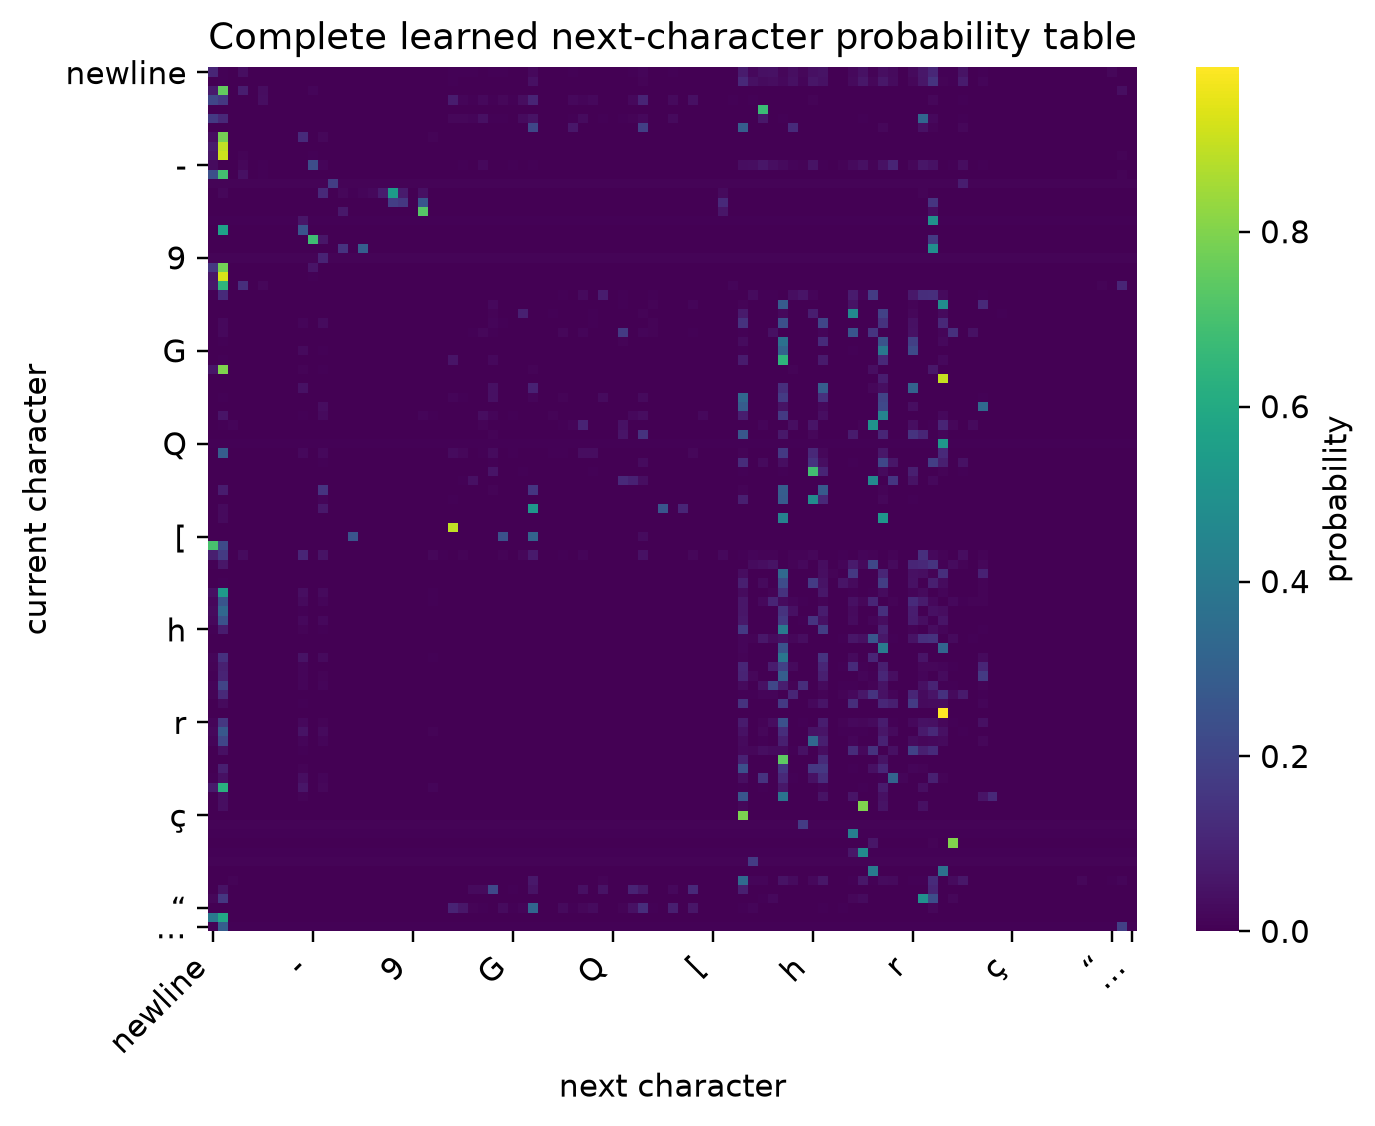

after 'q': [('u', 0.988), ('.', 0.002), ('!', 0.0), ('"', 0.0), ('&', 0.0)]
after 'space': [('t', 0.144), ('a', 0.111), ('w', 0.071), ('m', 0.061), ('o', 0.061)]
after '.': [('space', 0.691), ('newline', 0.239), ('"', 0.042), ('”', 0.01), ("'", 0.005)]
after ',': [('space', 0.911), ('newline', 0.056), ('”', 0.011), ('"', 0.01), ('-', 0.004)]


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


def display_label(character):
    """Use visible labels for whitespace characters in the heatmap."""
    return {" ": "space", "\n": "newline", "\t": "tab"}.get(character, character)


# Keep every row and column: this is the complete learned vocabulary matrix.
all_characters = [id_to_character[index] for index in range(alphabet_size)]
all_labels = [display_label(character) for character in all_characters]
heatmap = trained_transition_probabilities.numpy()

# The figure is compact; sparse ticks keep the full grid from becoming cluttered.
tick_positions = list(range(0, alphabet_size, 10))
if tick_positions[-1] != alphabet_size - 1:
    tick_positions.append(alphabet_size - 1)

fig, axis = plt.subplots(figsize=(6.4, 5.2), dpi=110)
sns.heatmap(
    heatmap,
    ax=axis,
    cmap="viridis",
    vmin=0,
    vmax=heatmap.max(),
    xticklabels=False,
    yticklabels=False,
    cbar_kws={"label": "probability"},
)
axis.set_xticks([index + 0.5 for index in tick_positions])
axis.set_xticklabels(
    [all_labels[index] for index in tick_positions],
    rotation=45,
    ha="right",
)
axis.set_yticks([index + 0.5 for index in tick_positions])
axis.set_yticklabels([all_labels[index] for index in tick_positions])
axis.set_xlabel("next character")
axis.set_ylabel("current character")
axis.set_title("Complete learned next-character probability table")
fig.tight_layout()
plt.show()

for current_character in ["q", " ", ".", ","]:
    if current_character not in character_to_id:
        continue
    row = trained_transition_probabilities[character_to_id[current_character]]
    likely_ids = torch.topk(row, k=min(5, alphabet_size)).indices
    likely_next = [
        (display_label(id_to_character[int(index)]), round(float(row[index]), 3))
        for index in likely_ids
    ]
    print(f"after {display_label(current_character)!r}: {likely_next}")

## Generate text one character at a time

Generation starts from a single character. At each step, sample one next character from the corresponding probability row, append it to the output, and use it as the next context. Temperature changes how sharply the probabilities are concentrated: values below one make common transitions more dominant; values above one make unusual transitions more likely.

In [11]:
def sample_next_character(current_id, probabilities, generator, temperature=1.0):
    if temperature <= 0:
        raise ValueError('temperature must be positive')
    log_probabilities = probabilities[current_id].clamp_min(1e-12).log()
    adjusted_probabilities = torch.softmax(log_probabilities / temperature, dim=0)
    return int(torch.multinomial(adjusted_probabilities, 1, generator=generator).item())


def generate_text(start_character, number_of_characters, temperature=1.0, seed=0):
    generator = torch.Generator().manual_seed(seed)
    generated_ids = [character_to_id[start_character]]
    for _ in range(number_of_characters - 1):
        next_id = sample_next_character(generated_ids[-1], trained_transition_probabilities, generator, temperature)
        generated_ids.append(next_id)
    return decode(generated_ids)


for temperature in [0.6, 1.0, 1.4]:
    print(f"\n--- temperature={temperature} ---")
    print(generate_text('T', 240, temperature=temperature, seed=42))


--- temperature=0.6 ---
The thed o wa me d bugre thofourene he the pere s hinge thesonnd ure monen ther fre tatheng d we, t ur whe ourat a re ie ainde athe he the s f s tis ass I
the asean pre ale hecheand asonthen tharen theaghand cathed theno the I more tond os 

--- temperature=1.0 ---
The uld mo wa me ry tores, parerene Fe thaby, tis hixce bllanendsud; mosenowon Cle esabece ed. s, t uruthe jorate trifie ailee atheflitore; ke, thioveshe Ared aseant rt ole hechonere sontirirofthen

iovasurdocay tovenge htochiom vertond os 

--- temperature=1.4 ---
The uld morof ve ryClorelye;x] wheshinuthaby,

is hüxce bllanendsud; mosenowonrCæmo tabece Busy ett uruthe-joratel rifiexay
seva deflivean;-ke, dillveshe Aret apean: r! ule hachonereedontirnERhtreg

iovasurdocaycedd hano toch, m veply waks 


## What this model can and cannot learn

The model can learn local spelling and punctuation regularities because those are visible in one-character transitions. It cannot remember a topic across a sentence, choose a word from a long-range grammatical context, or represent that the same character means different things in different words. Those limitations are consequences of the one-character context, not failures of the sampling code.

The next project will widen the context window and replace the fixed probability table with a model that predicts from a sequence of characters. The training target will stay the same: predict the next character from the characters that came before it.